# E14: Fused Gromov-Wasserstein

In [1]:
from __future__ import annotations
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy as sp
from scipy.spatial.distance import cdist
from scipy import sparse
from scipy.stats import pearsonr
import ot
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from __future__ import annotations
from typing import Any, Dict, Hashable, Iterable, List, Sequence, Tuple, Union, Optional
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue, \
                              combine_transport_plans, \
                              convert_ensembl_to_gene_symbols, \
                              nearest_neighbor_cell_type, \
                              nn_gene_r2, \
                              plot_ot_transport_by_celltype
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded, \
                                         plot_first_two_dims
import torch
from pytorch_helpers import fit_mlp
import perturbot
from perturbot.match import get_coupling_egw_labels_ott
import celltypist
from celltypist import models
#from perturbot.predict import train_mlp
%matplotlib inline

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [210]:
import re
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import pearsonr
from urllib.parse import urlparse


def ortholog_pearson_r2_by_celltype_biomart(
    adata_h,
    adata_m,
    group_key: str = "shared_cell_type",
    *,
    # If var_names are Ensembl IDs, leave these as None.
    human_ensembl_col: str | None = None,
    mouse_ensembl_col: str | None = None,
    # If present, used as fallback if BioMart names are missing.
    human_symbol_col: str | None = "gene_symbol",
    mouse_symbol_col: str | None = "gene_symbol",
    # BioMart options:
    biomart_host: str = "www.ensembl.org",
    human_dataset: str = "hsapiens_gene_ensembl",
    one2one_only: bool = True,
    # Correlation / regression options:
    min_common_celltypes: int = 5,
    drop_constant: bool = True,
) -> pd.DataFrame:
    """
    Compute Pearson R^2 for human↔mouse ortholog gene pairs across grouped cell types,
    and also compute a 1-parameter best-fit slope through the origin for:

        (mouse_group_mean) on x axis
        (human_group_mean) on y axis

    Output columns include:
      mouse_gene_name, human_gene_name, pearson_r, r2, slope_through_origin, n_cell_types,
      mouse_ensembl_id, human_ensembl_id
    """

    def strip_ensembl_version(x: str) -> str:
        return re.sub(r"\.\d+$", "", str(x))

    def get_ens_series_and_symbol_series(adata, ensembl_col, symbol_col):
        if ensembl_col is None:
            ens_ids = pd.Index([strip_ensembl_version(str(x)) for x in adata.var_names])
            ens_series = pd.Series(ens_ids.values, index=adata.var_names, name="ensembl_id")
        else:
            if ensembl_col not in adata.var.columns:
                raise KeyError(f"'{ensembl_col}' not found in adata.var")
            ens_series = adata.var[ensembl_col].astype(str).map(strip_ensembl_version)

        sym_series = adata.var[symbol_col].astype(str) if (symbol_col and symbol_col in adata.var.columns) else None
        return ens_series, sym_series

    def build_first_index_map(ens_series: pd.Series) -> dict[str, int]:
        m = {}
        for idx, eid in enumerate(ens_series.values):
            if eid and eid not in m:
                m[eid] = idx
        return m

    def group_means_for_var_indices(adata, group_key, var_indices: np.ndarray):
        X = adata.X[:, var_indices]
        if sparse.issparse(X):
            X = X.tocsr()

        groups = adata.obs[group_key].astype(str).values
        uniq = pd.Index(pd.unique(groups))

        group_to_row = {g: i for i, g in enumerate(uniq)}
        row_idx = np.array([group_to_row[g] for g in groups], dtype=int)
        col_idx = np.arange(len(groups), dtype=int)
        data = np.ones(len(groups), dtype=float)
        G = sparse.csr_matrix((data, (row_idx, col_idx)), shape=(len(uniq), len(groups)))

        counts = np.asarray(G.sum(axis=1)).ravel()
        sums = G @ X  # (n_groups x n_genes_selected)
        if sparse.issparse(sums):
            sums = sums.toarray()
        means = sums / counts[:, None]
        return uniq, means

    def pick_name(biomart_name, fallback_sym_series, fallback_index, fallback_id):
        if biomart_name is not None:
            s = str(biomart_name).strip()
            if s and s.lower() != "nan":
                return s
        if fallback_sym_series is not None:
            try:
                s = str(fallback_sym_series.iloc[fallback_index]).strip()
                if s and s.lower() != "nan":
                    return s
            except Exception:
                pass
        return str(fallback_id)

    # Validate group key
    if group_key not in adata_h.obs.columns:
        raise KeyError(f"`group_key='{group_key}'` not found in human .obs")
    if group_key not in adata_m.obs.columns:
        raise KeyError(f"`group_key='{group_key}'` not found in mouse .obs")

    # Gene ids
    h_ens, h_sym = get_ens_series_and_symbol_series(adata_h, human_ensembl_col, human_symbol_col)
    m_ens, m_sym = get_ens_series_and_symbol_series(adata_m, mouse_ensembl_col, mouse_symbol_col)
    h_map = build_first_index_map(h_ens)
    m_map = build_first_index_map(m_ens)

    # BioMart host sanitize (pybiomart expects bare hostname)
    host = biomart_host.strip()
    if host.startswith("http://") or host.startswith("https://"):
        host = urlparse(host).netloc

    # Fetch orthologs
    try:
        from pybiomart import Dataset
    except ModuleNotFoundError as e:
        raise ModuleNotFoundError(
            "pybiomart is not installed. Install with `pip install pybiomart` "
            "or use a workflow that reads a saved BioMart CSV."
        ) from e

    human = Dataset(name=human_dataset, host=host)

    attrs = [
        "ensembl_gene_id",
        "external_gene_name",
        "mmusculus_homolog_ensembl_gene",
        "mmusculus_homolog_associated_gene_name",
        "mmusculus_homolog_orthology_type",
    ]
    ortho = human.query(attributes=attrs).copy()

    # Normalize column names defensively
    col_map = {
        "ensembl_gene_id": "human_ens",
        "external_gene_name": "human_name_biomart",
        "mmusculus_homolog_ensembl_gene": "mouse_ens",
        "mmusculus_homolog_associated_gene_name": "mouse_name_biomart",
        "mmusculus_homolog_orthology_type": "orthology_type",
        "Gene stable ID": "human_ens",
        "Gene name": "human_name_biomart",
        "Mouse gene stable ID": "mouse_ens",
        "Mouse gene name": "mouse_name_biomart",
        "Mouse homology type": "orthology_type",
    }
    ortho = ortho.rename(columns={c: col_map.get(c, c) for c in ortho.columns})

    if not {"human_ens", "mouse_ens"}.issubset(set(ortho.columns)):
        raise RuntimeError(f"BioMart query did not return expected columns. Got: {list(ortho.columns)}")

    ortho["human_ens"] = ortho["human_ens"].astype(str).map(strip_ensembl_version)
    ortho["mouse_ens"] = ortho["mouse_ens"].astype(str).map(strip_ensembl_version)

    if one2one_only and "orthology_type" in ortho.columns:
        ortho = ortho[ortho["orthology_type"] == "ortholog_one2one"].copy()

    ortho = ortho[ortho["human_ens"].isin(h_map) & ortho["mouse_ens"].isin(m_map)].copy()
    ortho = ortho.drop_duplicates(subset=["human_ens", "mouse_ens"]).reset_index(drop=True)

    if ortho.empty:
        raise RuntimeError("No overlapping orthologs found between BioMart and your AnnData objects.")

    # Var indices aligned to ortho rows
    h_indices = np.array([h_map[eid] for eid in ortho["human_ens"].values], dtype=int)
    m_indices = np.array([m_map[eid] for eid in ortho["mouse_ens"].values], dtype=int)

    # Group means
    h_groups, H_means = group_means_for_var_indices(adata_h, group_key, h_indices)
    m_groups, M_means = group_means_for_var_indices(adata_m, group_key, m_indices)

    common = h_groups.intersection(m_groups)
    if len(common) < min_common_celltypes:
        raise RuntimeError(
            f"Only {len(common)} shared cell types between species (need >= {min_common_celltypes})."
        )

    h_pos = {g: i for i, g in enumerate(h_groups)}
    m_pos = {g: i for i, g in enumerate(m_groups)}
    h_rows = np.array([h_pos[g] for g in common], dtype=int)
    m_rows = np.array([m_pos[g] for g in common], dtype=int)

    Y = H_means[h_rows, :]  # human grouped means (n_common x n_genes)
    X = M_means[m_rows, :]  # mouse grouped means (n_common x n_genes)

    # Compute Pearson r, r^2, and slope through origin
    n = ortho.shape[0]
    keep = np.ones(n, dtype=bool)
    pearson_r = np.empty(n, dtype=float)
    r2 = np.empty(n, dtype=float)
    slope = np.empty(n, dtype=float)

    for k in range(n):
        x = X[:, k]
        y = Y[:, k]

        if drop_constant and (np.isclose(np.var(x), 0.0) or np.isclose(np.var(y), 0.0)):
            keep[k] = False
            continue

        r, _ = pearsonr(x, y)
        pearson_r[k] = r
        r2[k] = r * r

        denom = float(np.dot(x, x))
        slope[k] = (float(np.dot(x, y)) / denom) if denom > 0 else np.nan

    ortho_kept = ortho.loc[keep].reset_index(drop=True)
    pearson_r = pearson_r[keep]
    r2 = r2[keep]
    slope = slope[keep]

    # Names (BioMart first)
    mouse_names, human_names = [], []
    for _, row in ortho_kept.iterrows():
        hi = h_map[row["human_ens"]]
        mi = m_map[row["mouse_ens"]]
        human_names.append(pick_name(row.get("human_name_biomart"), h_sym, hi, row["human_ens"]))
        mouse_names.append(pick_name(row.get("mouse_name_biomart"), m_sym, mi, row["mouse_ens"]))

    res = pd.DataFrame(
        {
            "mouse_gene_name": mouse_names,
            "human_gene_name": human_names,
            "slope_through_origin": slope,
            "pearson_r": pearson_r,
            "r2": r2,
            "n_cell_types": int(len(common)),
            "mouse_ensembl_id": ortho_kept["mouse_ens"].values,
            "human_ensembl_id": ortho_kept["human_ens"].values,
        }
    ).sort_values("r2", ascending=False, ignore_index=True)

    return res

In [224]:
def plot_grouped_gene_means(
    adata_h,
    adata_m,
    human_ensembl_id: str,
    mouse_ensembl_id: str,
    *,
    group_key: str = "shared_cell_type",
    human_ensembl_col: str | None = None,
    mouse_ensembl_col: str | None = None,
    human_label: str | None = None,
    mouse_label: str | None = None,
    figsize=(6, 6),
    annotate: bool = True,
):
    """
    Scatter plot of group-averaged expression for a human gene vs a mouse gene,
    with cell type labels next to points.

    Assumes adata_h/adata_m are normalized, log1p, scaled (or comparable).

    If var_names are Ensembl IDs: leave *_ensembl_col=None.
    If var_names are symbols and Ensembl IDs are in .var: set *_ensembl_col to that column.
    """

    def strip_version(x: str) -> str:
        return re.sub(r"\.\d+$", "", str(x))

    def find_var_index(adata, target_id: str, ensembl_col: str | None) -> int:
        target_id = strip_version(target_id)
        if ensembl_col is None:
            # var_names are Ensembl IDs
            ids = pd.Index([strip_version(x) for x in adata.var_names])
            hits = np.where(ids == target_id)[0]
        else:
            if ensembl_col not in adata.var.columns:
                raise KeyError(f"'{ensembl_col}' not found in adata.var")
            ids = adata.var[ensembl_col].astype(str).map(strip_version).values
            hits = np.where(ids == target_id)[0]
        if len(hits) == 0:
            raise KeyError(f"Could not find gene id {target_id} in AnnData.")
        return int(hits[0])  # take first if duplicates

    def grouped_mean_for_var_index(adata, var_idx: int, group_key: str) -> pd.Series:
        if group_key not in adata.obs.columns:
            raise KeyError(f"'{group_key}' not found in adata.obs")
        groups = adata.obs[group_key].astype(str).values
        uniq = pd.Index(pd.unique(groups))

        x = adata.X[:, var_idx]
        if sparse.issparse(x):
            x = x.toarray().ravel()
        else:
            x = np.asarray(x).ravel()

        df = pd.DataFrame({group_key: groups, "expr": x})
        return df.groupby(group_key)["expr"].mean()

    # Locate genes
    h_idx = find_var_index(adata_h, human_ensembl_id, human_ensembl_col)
    m_idx = find_var_index(adata_m, mouse_ensembl_id, mouse_ensembl_col)

    # Group means
    h_means = grouped_mean_for_var_index(adata_h, h_idx, group_key)
    m_means = grouped_mean_for_var_index(adata_m, m_idx, group_key)

    # Common cell types
    common = h_means.index.intersection(m_means.index)
    if len(common) == 0:
        raise RuntimeError("No overlapping group labels between human and mouse for group_key.")

    x = m_means.loc[common].values
    y = h_means.loc[common].values
    labels = common.tolist()

    # Plot
    plt.figure(figsize=figsize)
    plt.scatter(x, y)

    if annotate:
        # small offsets so text isn't directly on top of the marker
        dx = 0.01 * (np.nanmax(x) - np.nanmin(x) + 1e-9)
        dy = 0.01 * (np.nanmax(y) - np.nanmin(y) + 1e-9)
        for xi, yi, lab in zip(x, y, labels):
            plt.text(xi + dx, yi + dy, lab, fontsize=9)

    mx = mouse_label if mouse_label is not None else mouse_ensembl_id
    hy = human_label if human_label is not None else human_ensembl_id
    plt.xlabel(f"Mouse mean (grouped): {mx}")
    plt.ylabel(f"Human mean (grouped): {hy}")
    plt.title(f"Grouped means by {group_key}")
    plt.tight_layout()
    plt.show()

In [225]:
def ortholog_cell_distances(
    adata_mouse,
    adata_human,
    ortholog_df: pd.DataFrame,
    num_genes: int,
    *,
    # If var_names are Ensembl IDs, leave these as None.
    mouse_ensembl_col: str | None = None,
    human_ensembl_col: str | None = None,
    # Which layer to use (None => adata.X)
    layer_mouse: str | None = None,
    layer_human: str | None = None,
    # Column names expected from ortholog_pearson_r2_by_celltype_biomart output
    mouse_id_col: str = "mouse_ensembl_id",
    human_id_col: str = "human_ensembl_id",
    score_col: str = "r2",
    # Numerical options
    dtype=np.float32,
) -> np.ndarray:
    """
    Compute an (n_mouse_cells x n_human_cells) Euclidean distance matrix using the
    top `num_genes` ortholog pairs (ranked by `score_col`, e.g. R^2).

    Rows correspond to mouse cells in `adata_mouse` order.
    Columns correspond to human cells in `adata_human` order.

    Assumes both AnnData objects are scaled (so Euclidean is meaningful).
    """

    if num_genes <= 0:
        raise ValueError("num_genes must be a positive integer.")

    for col in (mouse_id_col, human_id_col, score_col):
        if col not in ortholog_df.columns:
            raise KeyError(f"ortholog_df is missing required column '{col}'.")

    def strip_ensembl_version(x: str) -> str:
        return re.sub(r"\.\d+$", "", str(x))

    def get_ensembl_ids_in_adata(adata, ensembl_col: str | None) -> np.ndarray:
        if ensembl_col is None:
            return np.array([strip_ensembl_version(x) for x in adata.var_names], dtype=object)
        if ensembl_col not in adata.var.columns:
            raise KeyError(f"'{ensembl_col}' not found in adata.var")
        return adata.var[ensembl_col].astype(str).map(strip_ensembl_version).to_numpy(dtype=object)

    def build_first_index_map(ids: np.ndarray) -> dict[str, int]:
        m = {}
        for i, gid in enumerate(ids):
            if gid and gid not in m:
                m[gid] = i
        return m

    def get_matrix(adata, layer: str | None):
        if layer is None:
            return adata.X
        if layer not in adata.layers:
            raise KeyError(f"Layer '{layer}' not found in AnnData.layers")
        return adata.layers[layer]

    # Prepare ortholog list (top by score)
    ort = ortholog_df[[mouse_id_col, human_id_col, score_col]].copy()
    ort[mouse_id_col] = ort[mouse_id_col].astype(str).map(strip_ensembl_version)
    ort[human_id_col] = ort[human_id_col].astype(str).map(strip_ensembl_version)
    ort = ort.sort_values(score_col, ascending=False, ignore_index=True)

    # Map gene IDs -> var indices in each adata
    mouse_ids = get_ensembl_ids_in_adata(adata_mouse, mouse_ensembl_col)
    human_ids = get_ensembl_ids_in_adata(adata_human, human_ensembl_col)
    mouse_map = build_first_index_map(mouse_ids)
    human_map = build_first_index_map(human_ids)

    # Keep only orthologs present in both adatas
    present = ort[mouse_id_col].isin(mouse_map) & ort[human_id_col].isin(human_map)
    ort = ort.loc[present].reset_index(drop=True)

    if ort.empty:
        raise RuntimeError("No ortholog pairs overlap with the genes present in both AnnData objects.")

    k = min(num_genes, len(ort))
    ort = ort.iloc[:k].copy()

    # Var indices aligned by ortholog pair order
    mouse_var_idx = np.array([mouse_map[g] for g in ort[mouse_id_col].to_numpy()], dtype=int)
    human_var_idx = np.array([human_map[g] for g in ort[human_id_col].to_numpy()], dtype=int)

    # Extract matrices (cells x genes) for selected orthologs
    Xm = get_matrix(adata_mouse, layer_mouse)[:, mouse_var_idx]
    Xh = get_matrix(adata_human, layer_human)[:, human_var_idx]

    # Convert to efficient numeric arrays
    if sparse.issparse(Xm):
        Xm = Xm.tocsr()
    if sparse.issparse(Xh):
        Xh = Xh.tocsr()

    # We compute squared Euclidean distances via:
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    # Then sqrt.
    def row_sq_norms(X):
        if sparse.issparse(X):
            return np.asarray(X.multiply(X).sum(axis=1)).ravel()
        return np.sum(np.asarray(X) ** 2, axis=1)

    m_norm = row_sq_norms(Xm).astype(dtype, copy=False)  # (n_mouse,)
    h_norm = row_sq_norms(Xh).astype(dtype, copy=False)  # (n_human,)

    # Cross term: Xm @ Xh.T
    # Keep in float32 unless you need extra precision
    if sparse.issparse(Xm) or sparse.issparse(Xh):
        cross = (Xm @ Xh.T).astype(dtype)
        if sparse.issparse(cross):
            cross = cross.toarray()
        else:
            cross = np.asarray(cross)
    else:
        Xm_dense = np.asarray(Xm, dtype=dtype)
        Xh_dense = np.asarray(Xh, dtype=dtype)
        cross = Xm_dense @ Xh_dense.T  # (n_mouse x n_human)

    # squared distances
    D2 = (m_norm[:, None] + h_norm[None, :] - 2.0 * cross).astype(dtype, copy=False)
    # numerical guard
    np.maximum(D2, 0.0, out=D2)
    D = np.sqrt(D2, dtype=dtype)

    return D

In [5]:
def run_entropic_fgw_transport(
    X_mouse_pca: np.ndarray,
    X_human_pca: np.ndarray,
    M_mouse_to_human: np.ndarray,
    epsilon: float,
    alpha: float,
    *,
    loss_fun: str = "square_loss",
    metric: str = "euclidean",
    squared: bool = True,
    normalize_C: bool = True,
    normalize_M: bool = True,
    p: np.ndarray | None = None,
    q: np.ndarray | None = None,
    max_iter: int = 200,
    tol: float = 1e-9,
    verbose: bool = False,
) -> np.ndarray:
    """
    Run entropic Fused Gromov-Wasserstein (FGW) using POT and return the transport plan.

    Parameters
    ----------
    X_mouse_pca : (n_mouse, d) array
        PCA coordinates for mouse cells (in their own PCA space).
    X_human_pca : (n_human, d) array
        PCA coordinates for human cells (in their own PCA space).
    M_mouse_to_human : (n_mouse, n_human) array
        Cross-space cost/distance matrix between mouse (rows) and human (cols).
        This is the "feature" (or correspondence) term in FGW.
    epsilon : float
        Entropic regularization strength (POT's epsilon for entropic FGW).
    alpha : float
        Weight on the GW (structure) term. alpha=1 => pure GW, alpha=0 => pure OT on M.
    loss_fun : str
        'square_loss' (default) or 'kl_loss' depending on your use case.
    metric : str
        Metric used to compute intra-space distances from PCA coords via ot.dist.
    squared : bool
        If True, use squared distances for intra-space cost matrices (common with square_loss).
    normalize_C : bool
        If True, rescale C1 and C2 to have comparable scale (divide by median of nonzero entries).
    normalize_M : bool
        If True, rescale M similarly (divide by median of nonzero entries).
    p, q : arrays or None
        Distributions over mouse/human cells. If None, uniform.
    max_iter : int
        Max outer iterations for solver.
    tol : float
        Convergence tolerance (passed to POT if supported).
    verbose : bool
        Verbosity.

    Returns
    -------
    T : (n_mouse, n_human) array
        Transport plan with mouse cells as rows and human cells as columns.
    """
    # --- imports here so function is easy to copy into environments ---
    try:
        import ot
        from ot.gromov import entropic_fused_gromov_wasserstein
    except Exception as e:
        raise ImportError(
            "This function requires the POT (Python Optimal Transport) package with "
            "`ot.gromov.entropic_fused_gromov_wasserstein` available.\n"
            "Try: pip install pot\n"
        ) from e

    X_mouse_pca = np.asarray(X_mouse_pca, dtype=float)
    X_human_pca = np.asarray(X_human_pca, dtype=float)
    M = np.asarray(M_mouse_to_human, dtype=float)

    if X_mouse_pca.ndim != 2 or X_human_pca.ndim != 2:
        raise ValueError("X_mouse_pca and X_human_pca must be 2D arrays (n_cells, n_pcs).")
    n_mouse = X_mouse_pca.shape[0]
    n_human = X_human_pca.shape[0]

    if M.shape != (n_mouse, n_human):
        raise ValueError(
            f"M_mouse_to_human must have shape (n_mouse, n_human)=({n_mouse},{n_human}), "
            f"got {M.shape}."
        )

    if not (epsilon > 0):
        raise ValueError("epsilon must be > 0.")
    if not (0 <= alpha <= 1):
        raise ValueError("alpha must be in [0, 1].")

    # distributions
    if p is None:
        p = np.full(n_mouse, 1.0 / n_mouse, dtype=float)
    else:
        p = np.asarray(p, dtype=float)
        if p.shape != (n_mouse,):
            raise ValueError(f"p must have shape ({n_mouse},), got {p.shape}.")
        p = p / p.sum()

    if q is None:
        q = np.full(n_human, 1.0 / n_human, dtype=float)
    else:
        q = np.asarray(q, dtype=float)
        if q.shape != (n_human,):
            raise ValueError(f"q must have shape ({n_human},), got {q.shape}.")
        q = q / q.sum()

    # intra-space cost matrices from PCA coordinates
    C1 = ot.dist(X_mouse_pca, X_mouse_pca, metric=metric)
    C2 = ot.dist(X_human_pca, X_human_pca, metric=metric)
    if squared:
        C1 = C1 ** 2
        C2 = C2 ** 2

    def _robust_scale(A: np.ndarray) -> np.ndarray:
        A = np.asarray(A, dtype=float)
        nz = A[A > 0]
        if nz.size == 0:
            return A
        med = np.median(nz)
        if med <= 0:
            return A
        return A / med

    if normalize_C:
        C1 = _robust_scale(C1)
        C2 = _robust_scale(C2)
    if normalize_M:
        M = _robust_scale(M)

    # Run entropic FGW (returns transport plan)
    # NOTE: POT signatures can vary slightly by version; these args match common releases.
    T = entropic_fused_gromov_wasserstein(
        M=M,
        C1=C1,
        C2=C2,
        p=p,
        q=q,
        loss_fun=loss_fun,
        epsilon=epsilon,
        alpha=alpha,
        max_iter=max_iter,
        tol=tol,
        verbose=verbose,
    )

    # Ensure correct shape and numeric sanity
    T = np.asarray(T, dtype=float)
    if T.shape != (n_mouse, n_human):
        raise RuntimeError(f"Unexpected transport plan shape {T.shape}, expected {(n_mouse, n_human)}.")

    return T

### Import data

In [188]:
human_dir = 'data/tabula_sapiens/'
human_adatas = top_n_organisms_from_species(human_dir, 2, 'human')
human1_adata = human_adatas[1]
# convert_ensembl_to_gene_symbols(human1_adata, species="human", make_unique=True)

In [189]:
mouse_dir = 'data/tabula_muris/'
mouse_adatas = top_n_organisms_from_species(mouse_dir, 2, 'mouse')
mouse1_adata = mouse_adatas[1]
# convert_ensembl_to_gene_symbols(mouse1_adata, species="mouse", make_unique=True)

### What genes correlate best between mice and humans?

In [190]:
shared_immune_cell_types = ['T cell','HPSC','macrophage','monocyte','neutrophil','plasma cell','erythrocyte','NK cell','B cell','basophil','dendritic cell']

In [191]:
human1_adata_immune = human1_adata[human1_adata.obs['shared_cell_type'].isin(shared_immune_cell_types)]
human1_adata = human1_adata_immune[human1_adata_immune.obs['tissue']=='lung']

In [192]:
mouse1_adata_immune = mouse1_adata[mouse1_adata.obs['shared_cell_type'].isin(shared_immune_cell_types)]
mouse1_adata = mouse1_adata_immune[mouse1_adata_immune.obs['tissue']=='lung']

In [193]:
mouse1_matched, human1_matched =  match_cells_by_celltype_tissue(mouse1_adata, human1_adata, cell_type_key='shared_cell_type')

In [194]:
human1_matched.layers["counts"] = human1_matched.X.copy()
sc.pp.normalize_total(human1_matched)
sc.pp.highly_variable_genes(human1_matched, layer="counts", flavor="seurat_v3")            
human1 = human1_matched[:, human1_matched.var['highly_variable']].copy()  
sc.pp.log1p(human1)
human1.layers["norm_logged"] = human1.X.copy()
sc.pp.scale(human1, max_value=10)

In [195]:
mouse1_matched.layers["counts"] = mouse1_matched.X.copy()
sc.pp.normalize_total(mouse1_matched)
sc.pp.highly_variable_genes(mouse1_matched, layer="counts", flavor="seurat_v3")            
mouse1 = mouse1_matched[:, mouse1_matched.var['highly_variable']].copy()  
sc.pp.log1p(mouse1)
mouse1.layers["norm_logged"] = mouse1.X.copy()
sc.pp.scale(mouse1, max_value=10)

In [226]:
correlated_orthologs = ortholog_pearson_r2_by_celltype_biomart(human1, mouse1)

In [227]:
correlated_orthologs.head(25)

,mouse_gene_name,human_gene_name,slope_through_origin,pearson_r,r2,n_cell_types,mouse_ensembl_id,human_ensembl_id
0,Ms4a2,MS4A2,2.152064,1.000000,1.000000,7,ENSMUSG00000024680,ENSG00000149534
1,Il27,IL27,0.696179,1.000000,1.000000,7,ENSMUSG00000044701,ENSG00000197272
2,Fcer1a,FCER1A,0.446860,1.000000,1.000000,7,ENSMUSG00000005339,ENSG00000179639
3,Cpa3,CPA3,0.996939,1.000000,1.000000,7,ENSMUSG00000001865,ENSG00000163751
4,Slc18a2,SLC18A2,1.587877,0.999992,0.999983,7,ENSMUSG00000025094,ENSG00000165646
5,Gata2,GATA2,0.931858,0.999803,0.999605,7,ENSMUSG00000015053,ENSG00000179348
6,Hdc,HDC,0.751097,0.998952,0.997905,7,ENSMUSG00000027360,ENSG00000140287
7,Cd300e,CD300E,1.342415,0.998536,0.997074,7,ENSMUSG00000048498,ENSG00000186407
8,Rundc3b,RUNDC3B,1.406528,0.997972,0.995948,7,ENSMUSG00000040570,ENSG00000105784
9,Il1rl1,IL1RL1,1.202337,0.996427,0.992867,7,ENSMUSG00000026069,ENSG00000115602


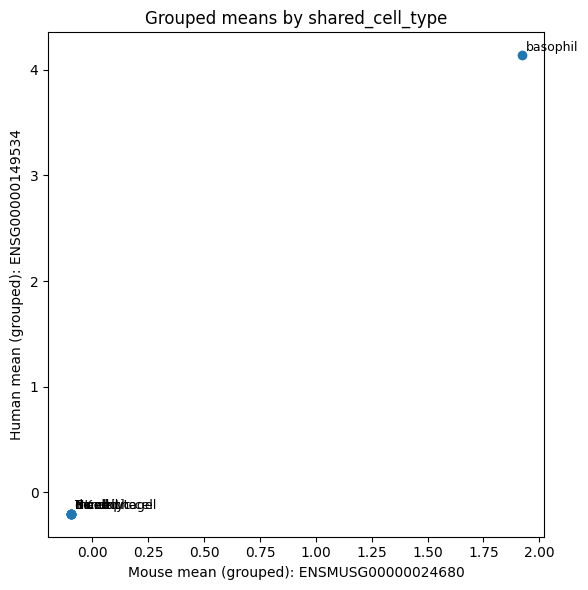

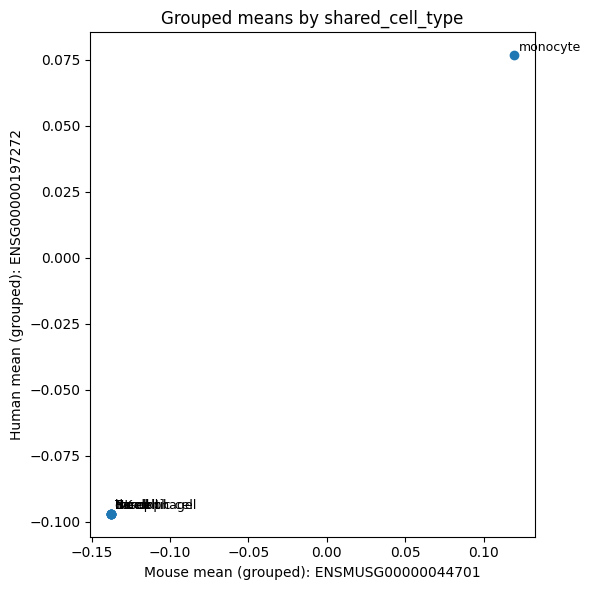

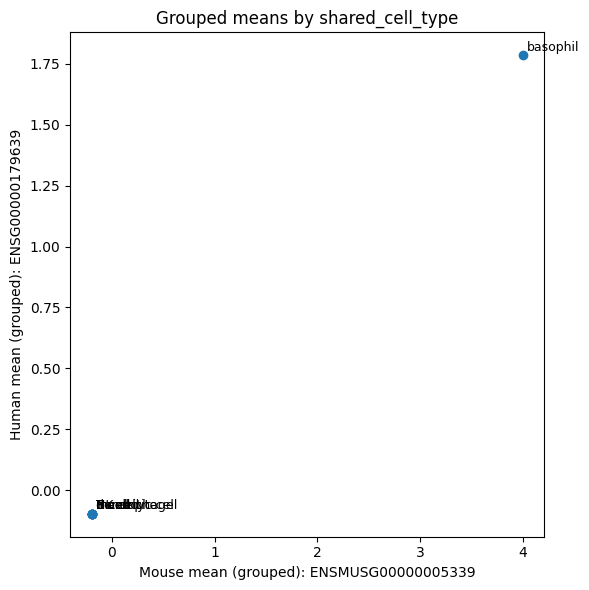

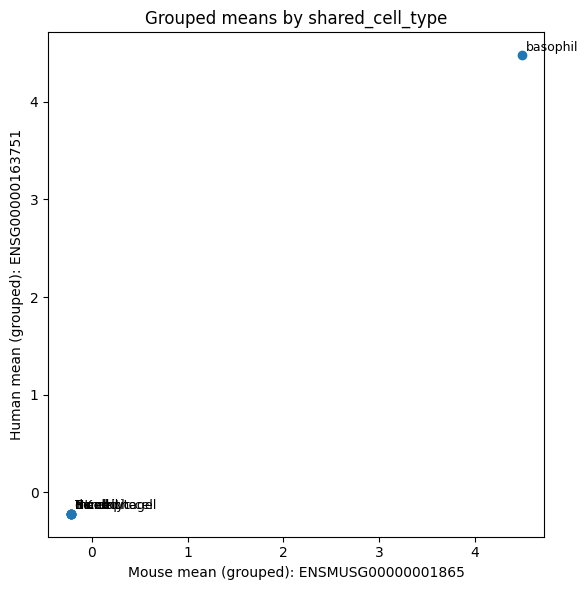

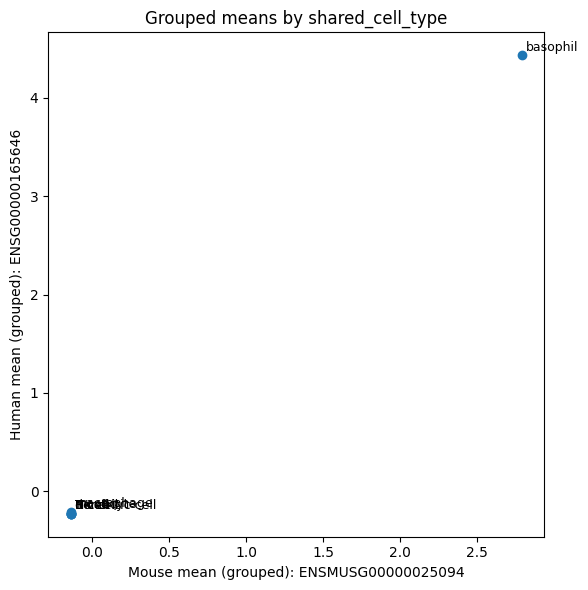

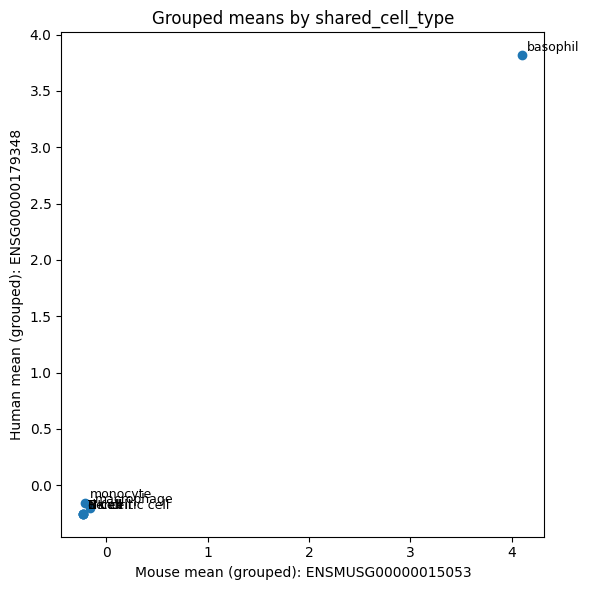

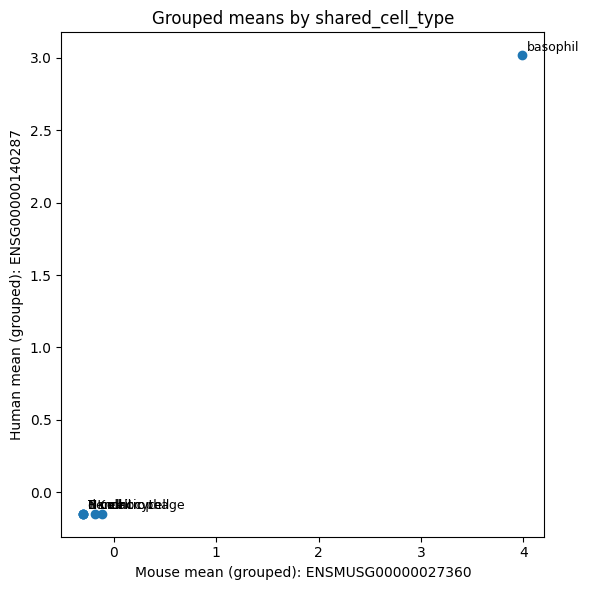

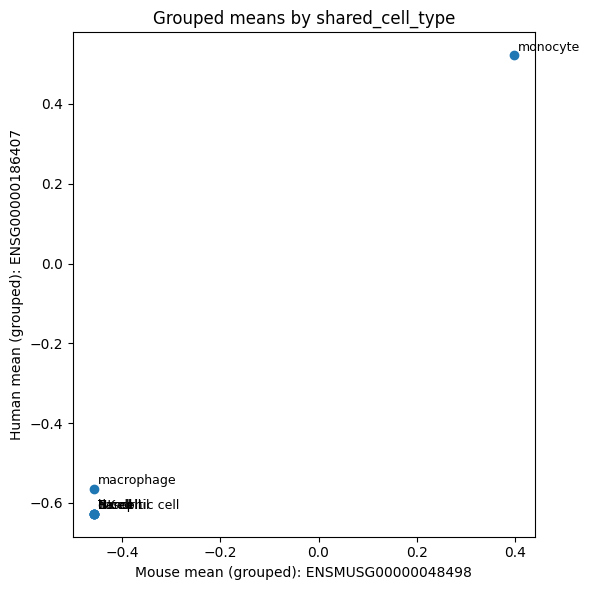

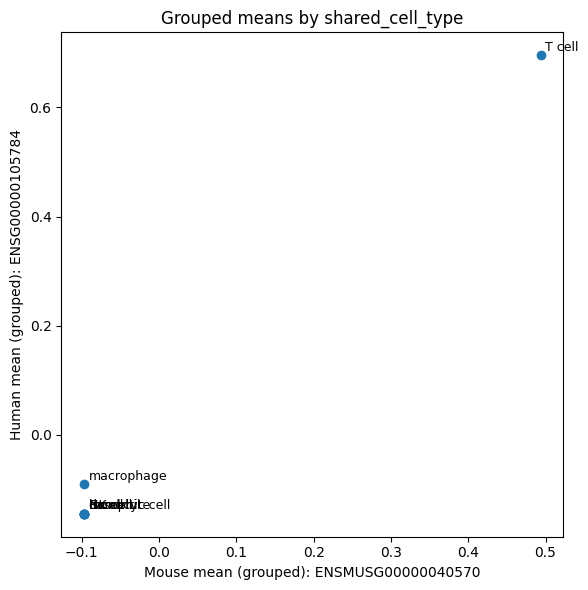

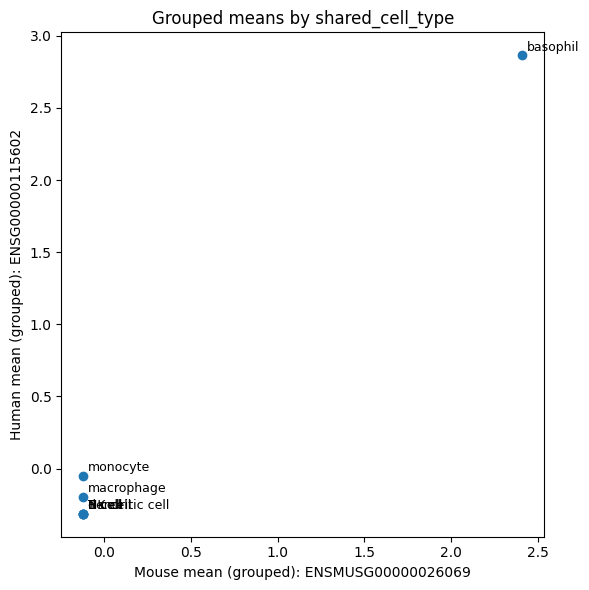

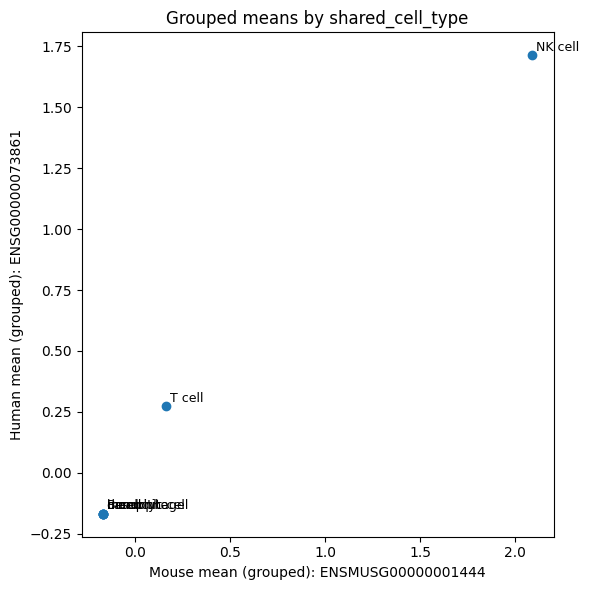

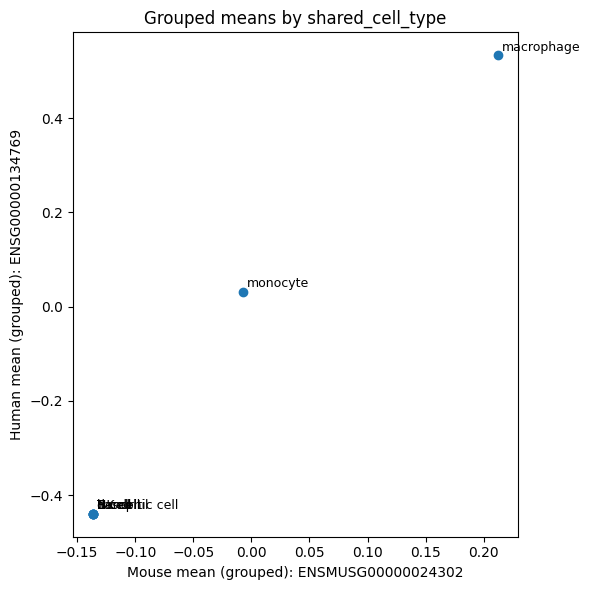

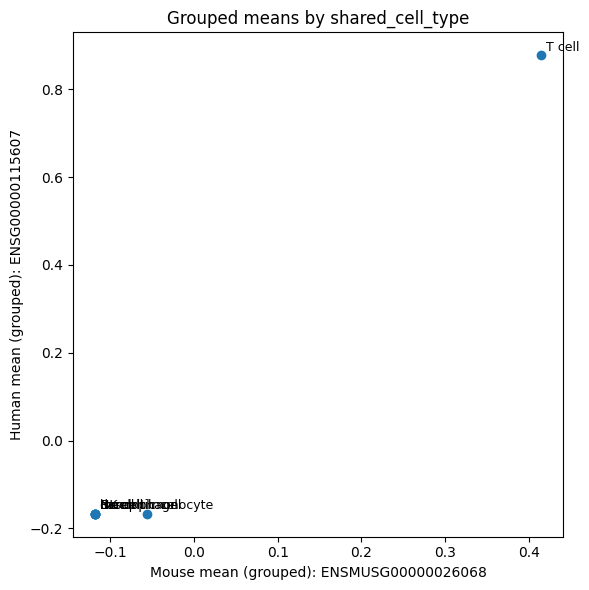

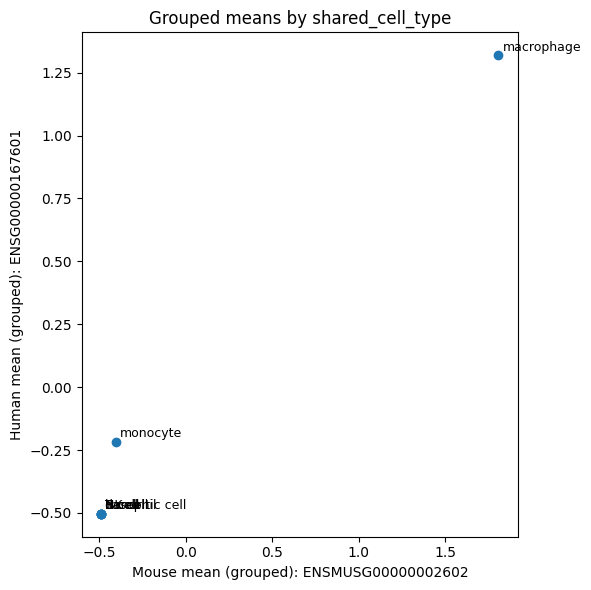

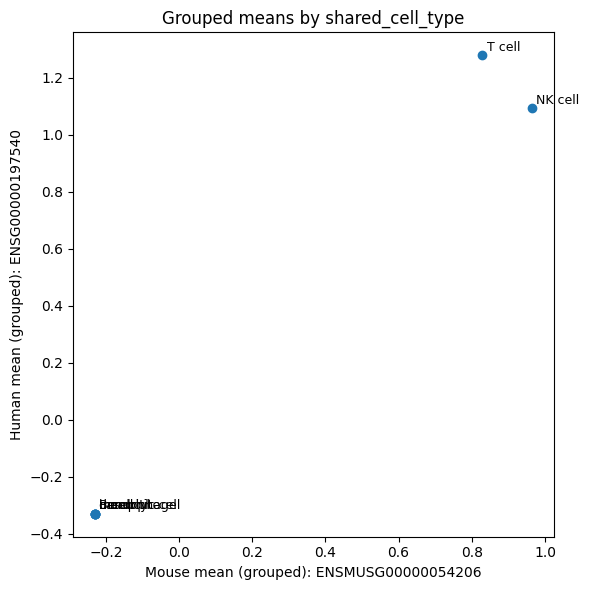

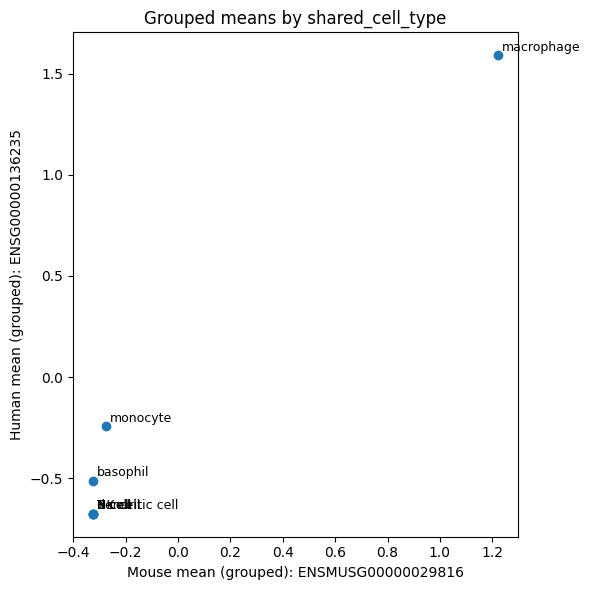

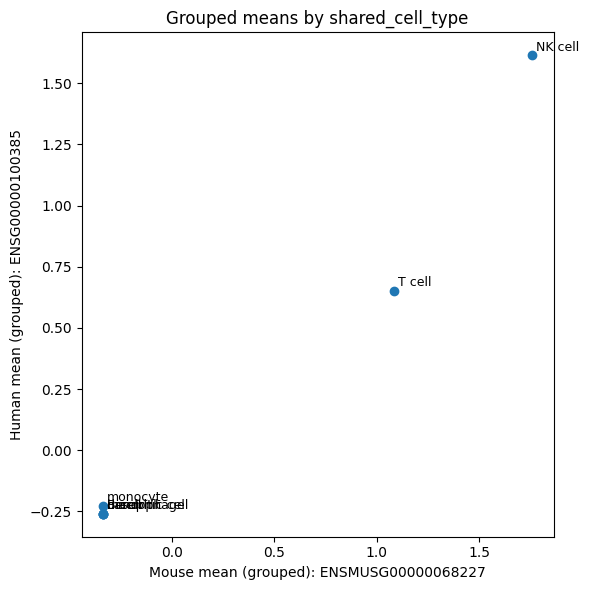

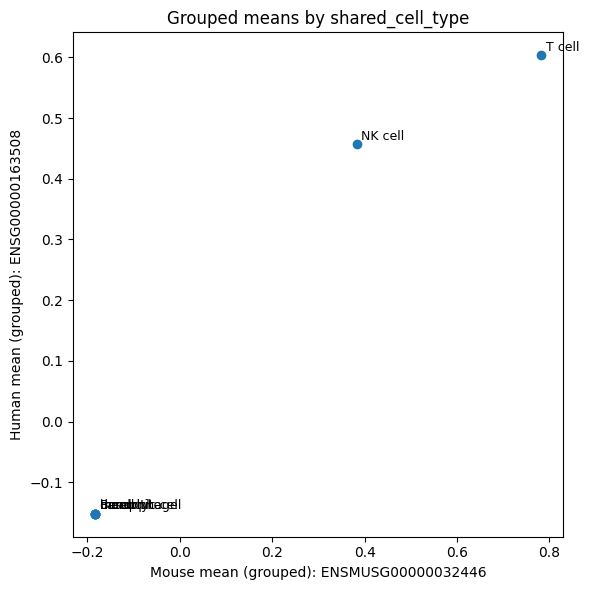

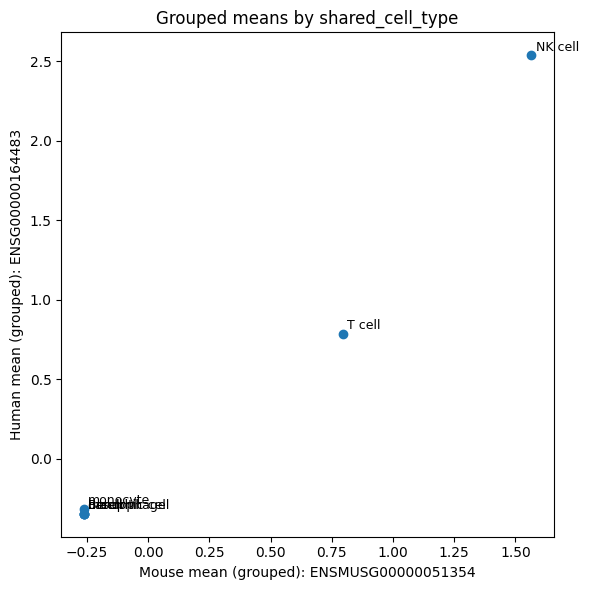

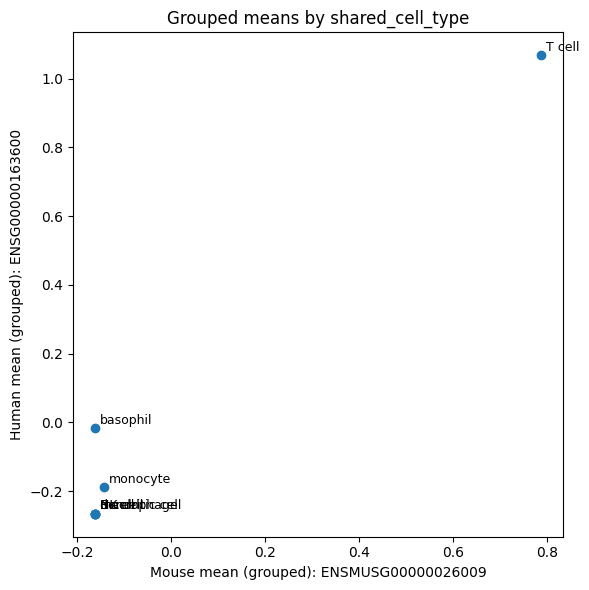

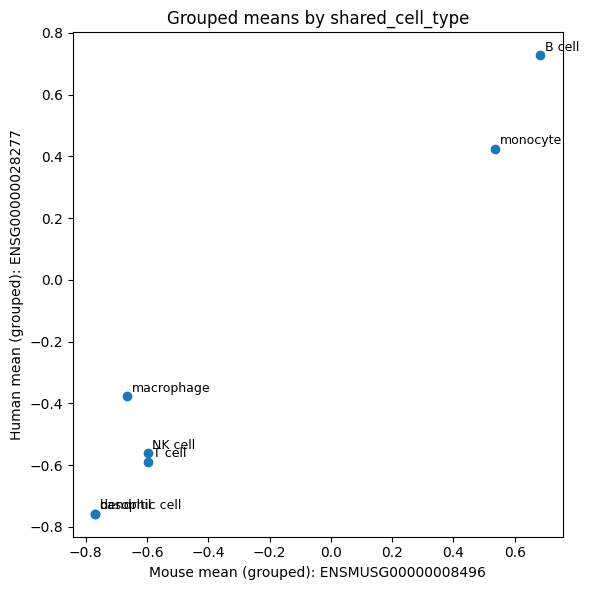

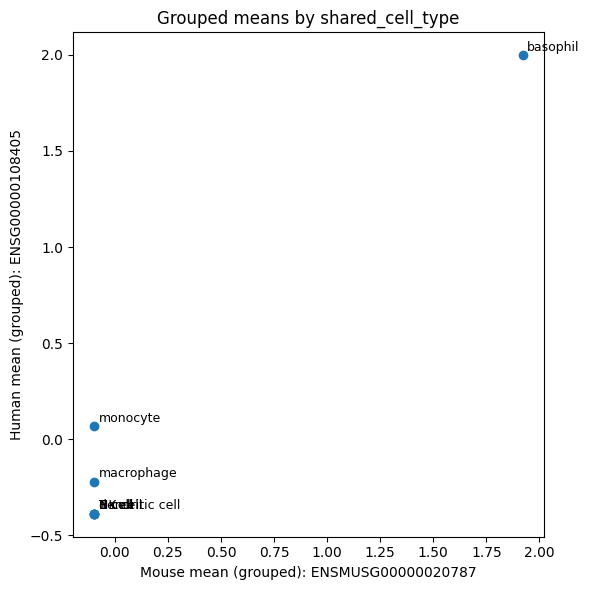

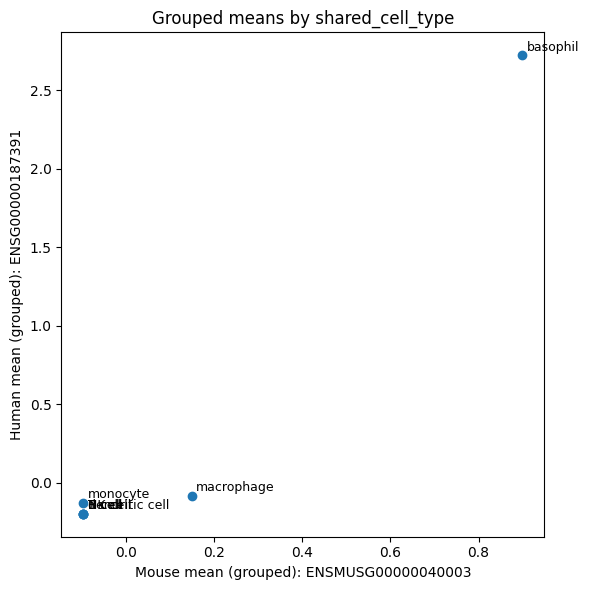

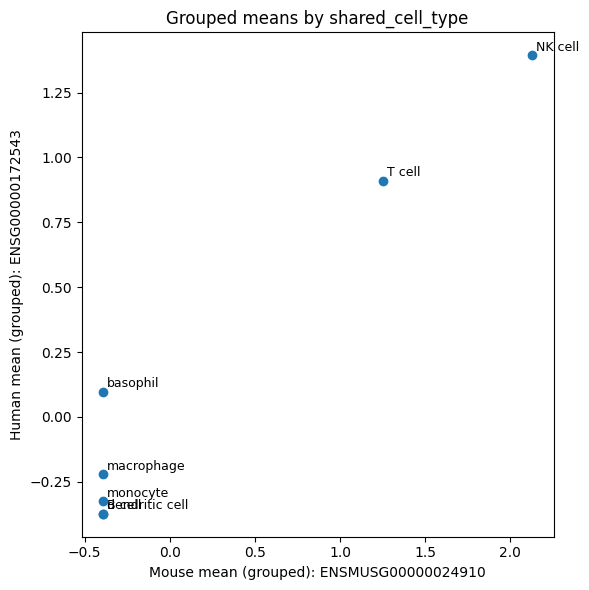

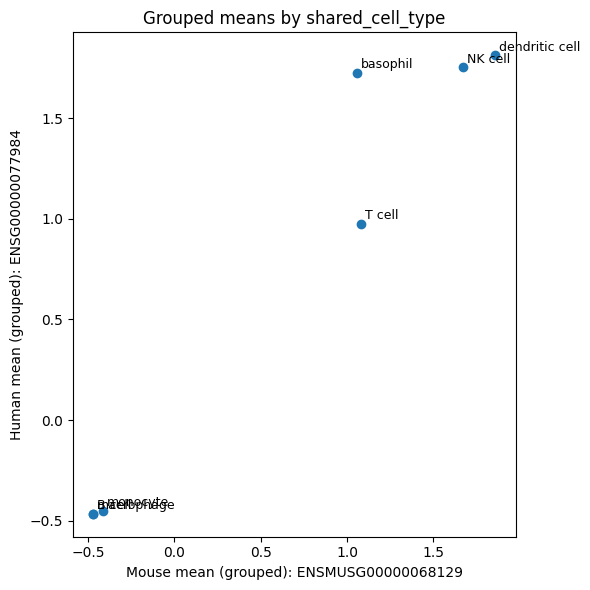

In [253]:
for i in range(25):
    plot_grouped_gene_means(
    human1, mouse1,
    human_ensembl_id=correlated_orthologs.loc[i,'human_ensembl_id'],
    mouse_ensembl_id=correlated_orthologs.loc[i,'mouse_ensembl_id'],
    group_key="shared_cell_type"
)

In [231]:
ortholog_M = ortholog_cell_distances(
    mouse1,
    human1,
    correlated_orthologs,
    100)

In [232]:
# generate PCA representations
sc.tl.pca(human1, n_comps=50, layer='norm_logged')
sc.tl.pca(mouse1, n_comps=50, layer='norm_logged')

In [233]:
mouse1

AnnData object with n_obs × n_vars = 213 × 2000
    obs: 'batch', 'tissue_FACS_droplet', 'free_annotation', 'n_counts', 'n_genes', 'louvain', 'leiden', 'age', 'method', 'donor_id', 'subtissue', 'tissue_free_annotation', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'FACS.selection', 'tissue_original', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    var: 'n_cells-0', 'n_cells-1', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable_rank', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'age_colors', 'citation', 'le

In [234]:
X_mouse_pca = mouse1.obsm['X_pca']
X_human_pca = human1.obsm['X_pca']

In [235]:
T = run_entropic_fgw_transport(X_mouse_pca, X_human_pca, ortholog_M, epsilon=0.01, alpha=0.5)

In [236]:
compute_mapping_acc(T, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'])

0.6948356807511737

In [239]:
eps_arr = []
alpha_arr = []
orths_arr = []
acc_arr = []

for eps in [0.001, 0.01, 0.1]:
    for alph in [0, 0.25, 0.5, 0.75, 1]:
        for orths in [10, 20, 50, 100]:
            ortholog_M = ortholog_cell_distances(mouse1, human1, correlated_orthologs, orths)
            T = run_entropic_fgw_transport(X_mouse_pca, X_human_pca, ortholog_M, epsilon=eps, alpha=alph)
            acc = compute_mapping_acc(T, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'])
            print('eps:', eps, 'alpha:', alph, 'orths:', orths, 'accuracy:', acc)
            eps_arr.append(eps)
            alpha_arr.append(alph)
            orths_arr.append(orths)
            acc_arr.append(acc)
        

eps: 0.001 alpha: 0 orths: 10 accuracy: 0.5446009389671361
eps: 0.001 alpha: 0 orths: 20 accuracy: 0.6291079812206573
eps: 0.001 alpha: 0 orths: 50 accuracy: 0.704225352112676
eps: 0.001 alpha: 0 orths: 100 accuracy: 0.6431924882629108
eps: 0.001 alpha: 0.25 orths: 10 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.25 orths: 20 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.25 orths: 50 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.25 orths: 100 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.5 orths: 10 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.5 orths: 20 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.5 orths: 50 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.5 orths: 100 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.75 orths: 10 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.75 orths: 20 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.75 orths: 50 accuracy: 0.5352112676056338
eps: 0.001 alpha: 0.75 orths: 100 accuracy: 0.5352112676056338
eps: 0.001 alpha: 1 o

In [250]:
eps = 0.1
alph = 0
orhts = 100
ortholog_M = ortholog_cell_distances(mouse1, human1, correlated_orthologs, orths)
T_opt = run_entropic_fgw_transport(X_mouse_pca, X_human_pca, ortholog_M, epsilon=eps, alpha=alph)
compute_mapping_acc(T_opt, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'])

0.9014084507042254

[[2.08554968e-04 2.88549028e-04 2.20205560e-06 ... 3.23331747e-05
  2.12083718e-05 2.59314139e-05]
 [3.06392345e-04 5.44528525e-04 1.48806609e-06 ... 3.32789940e-05
  3.67424719e-05 2.24757137e-05]
 [3.23128912e-06 2.40883164e-06 2.90138120e-04 ... 6.20793256e-07
  6.02122884e-07 9.94213723e-07]
 ...
 [1.58763394e-05 2.01134756e-05 1.03877901e-06 ... 3.90434119e-05
  3.31983664e-05 9.13268136e-05]
 [1.52533809e-05 2.04660858e-05 8.69130759e-07 ... 3.02205673e-05
  3.77154875e-05 2.47634595e-05]
 [1.10810455e-05 1.26403689e-05 5.17801918e-07 ... 3.75491355e-05
  3.14134620e-05 2.11785557e-05]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

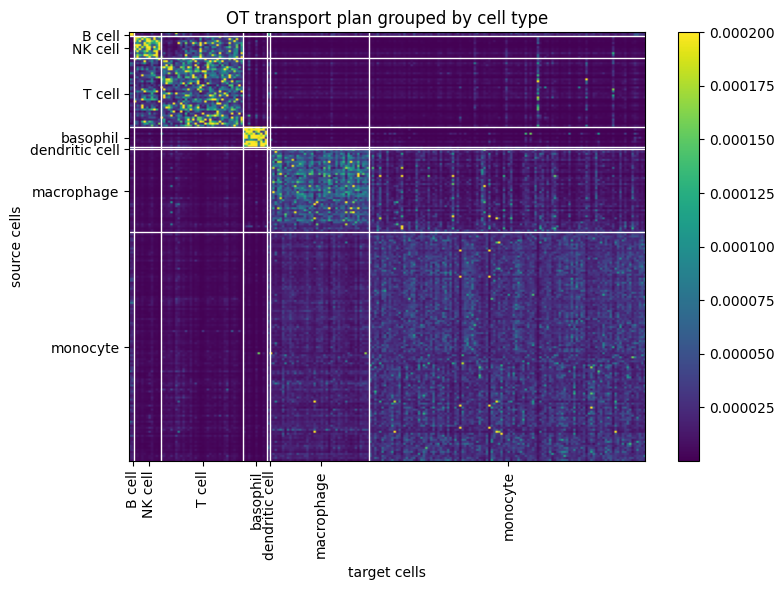

In [251]:
plot_ot_transport_by_celltype(T_opt, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'], vmax=0.0002)

[[3.01742197e-07 2.95951977e-08 3.33090432e-08 ... 3.97428648e-05
  3.22175743e-05 3.79146020e-05]
 [4.74557882e-08 3.54894739e-09 3.09560915e-09 ... 4.91378229e-05
  5.05635687e-05 3.14765431e-05]
 [3.39653773e-06 5.86349920e-07 6.12859132e-05 ... 2.99348256e-06
  3.11324121e-06 7.86531276e-06]
 ...
 [4.50447277e-08 4.37381814e-09 7.50680358e-09 ... 3.47720816e-05
  3.31155851e-05 6.35320291e-05]
 [3.44040371e-09 2.12390576e-10 4.43030264e-10 ... 3.74782052e-05
  4.23312262e-05 2.78852966e-05]
 [4.86998164e-09 3.01078455e-10 5.83274933e-10 ... 4.09122047e-05
  3.78979619e-05 2.68860610e-05]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

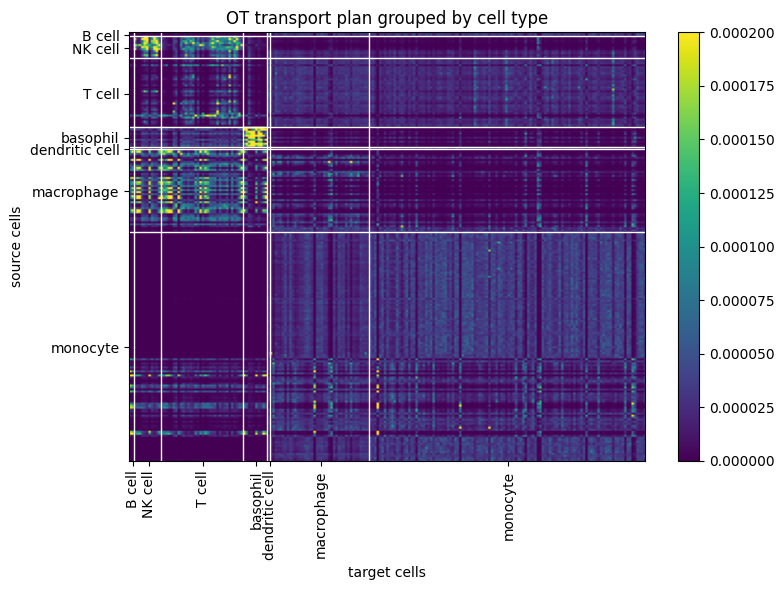

In [246]:
# alpha = 0.5
eps = 0.1
alph = 0.5
orhts = 100
ortholog_M = ortholog_cell_distances(mouse1, human1, correlated_orthologs, orths)
T_opt = run_entropic_fgw_transport(X_mouse_pca, X_human_pca, ortholog_M, epsilon=eps, alpha=alph)
compute_mapping_acc(T_opt, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'])
plot_ot_transport_by_celltype(T_opt, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'], vmax=0.0002)

[[1.34681915e-10 1.18468729e-12 1.50500141e-11 ... 2.82747501e-05
  2.86558360e-05 3.73824929e-05]
 [2.18378381e-12 8.67621550e-15 1.82128543e-13 ... 4.08990321e-05
  3.94531661e-05 2.86063363e-05]
 [3.03322602e-07 1.49563637e-08 4.56314327e-08 ... 5.34175776e-06
  5.97146012e-06 3.06174377e-05]
 ...
 [1.60544712e-10 1.51390099e-12 1.47319744e-11 ... 3.08582695e-05
  3.20007615e-05 4.12470975e-05]
 [1.01210919e-12 3.63837205e-15 6.65850305e-14 ... 4.61316162e-05
  4.60236407e-05 2.89019346e-05]
 [3.33080766e-12 1.40990475e-14 2.52283169e-13 ... 4.50637848e-05
  4.42949076e-05 3.11386452e-05]]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

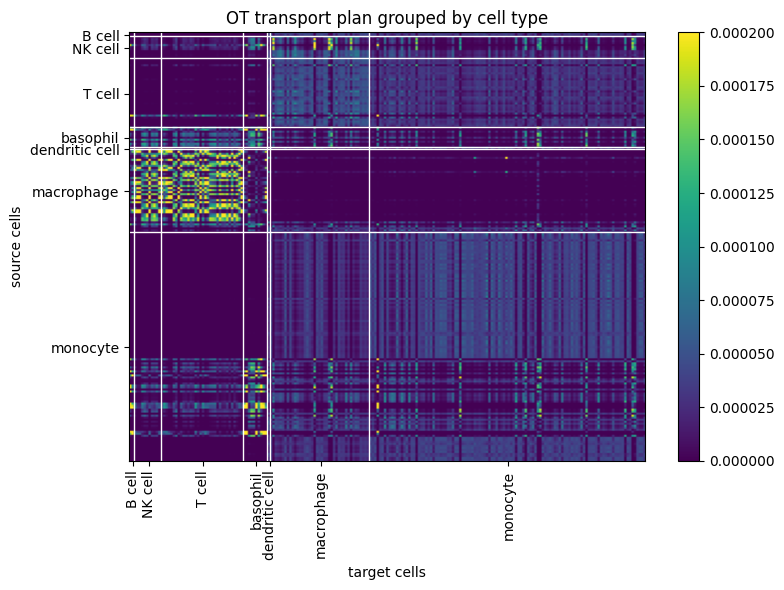

In [247]:
# alpha = 1
eps = 0.1
alph = 1
orhts = 100
ortholog_M = ortholog_cell_distances(mouse1, human1, correlated_orthologs, orths)
T_opt = run_entropic_fgw_transport(X_mouse_pca, X_human_pca, ortholog_M, epsilon=eps, alpha=alph)
compute_mapping_acc(T_opt, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'])
plot_ot_transport_by_celltype(T_opt, mouse1.obs['shared_cell_type'], human1.obs['shared_cell_type'], vmax=0.0002)

[[9.82020589e-05 4.56847183e-05 1.52467554e-04 ... 7.17699788e-06
  2.83434886e-05 1.66444519e-05]
 [2.53668344e-05 8.65733411e-06 7.29112002e-05 ... 2.60838065e-06
  9.63412352e-06 4.70413123e-06]
 [2.08554968e-04 2.88549028e-04 2.24930866e-05 ... 2.08893808e-05
  4.01632786e-05 4.09910346e-05]
 ...
 [7.40369777e-06 7.55003849e-06 1.08463014e-05 ... 3.00515697e-05
  3.20838707e-05 1.82367054e-05]
 [4.76390891e-06 4.26661328e-06 7.60989577e-06 ... 1.25210689e-05
  1.90298605e-05 2.75194463e-05]
 [1.35741027e-05 1.93943465e-05 6.48437543e-06 ... 1.56753771e-05
  1.78917180e-05 2.50332131e-05]]


(<Figure size 1200x1200 with 2 Axes>,
 <Axes: title={'center': 'OT transport plan grouped by cell type'}, xlabel='target cells', ylabel='source cells'>)

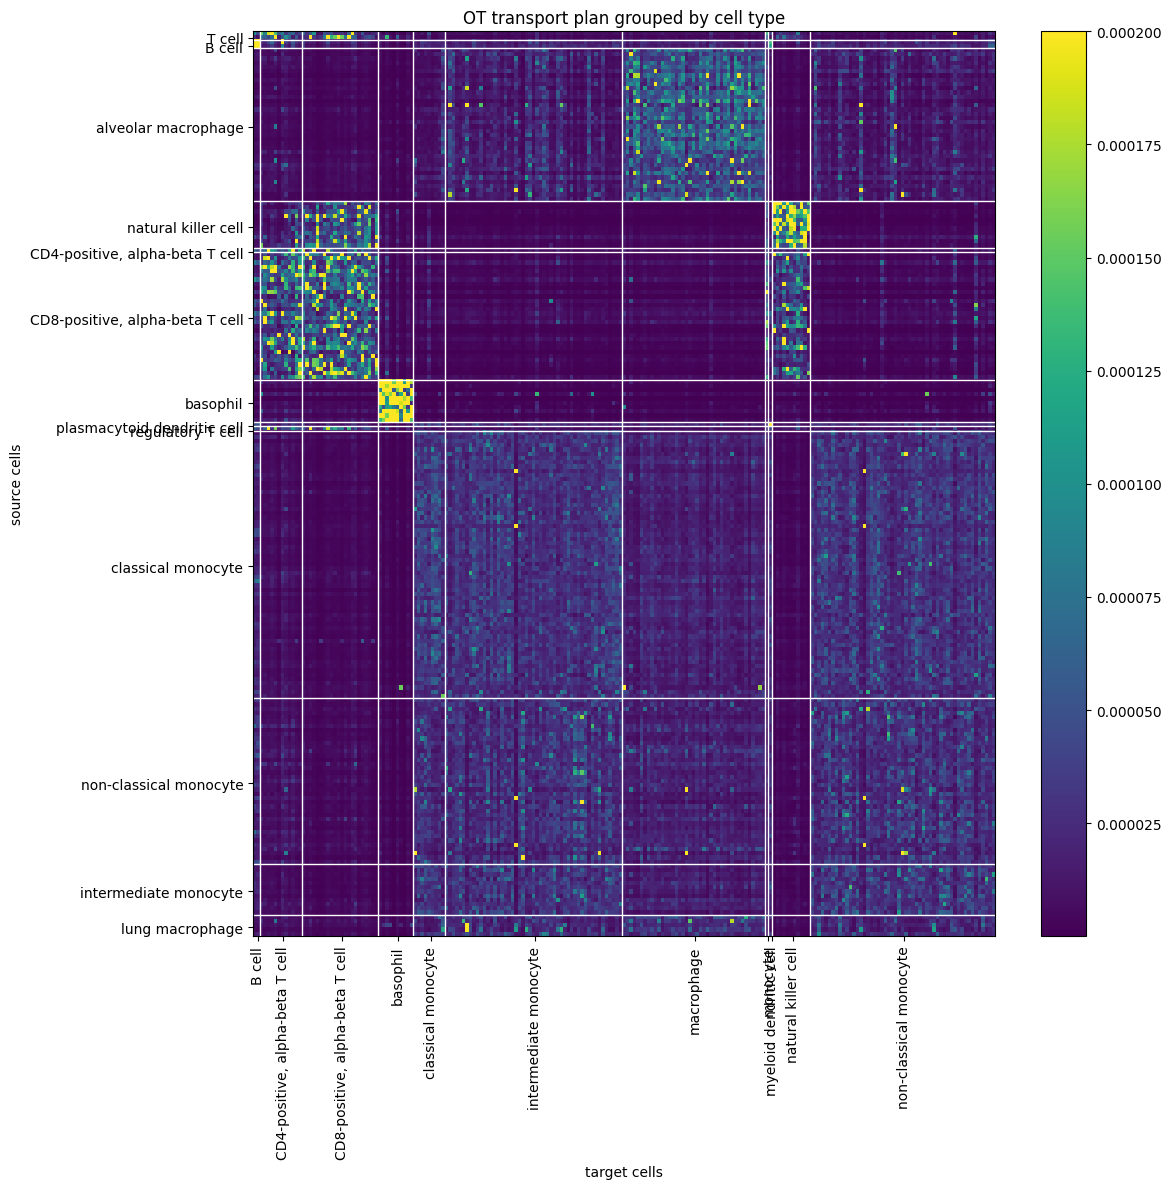

In [241]:
plot_ot_transport_by_celltype(T_opt, mouse1.obs['cell_type'], human1.obs['cell_type'], vmax=0.0002, figsize=(12, 12))

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
pd.crosstab(mouse_adatas[0].obs['shared_cell_type'],
                 mouse_adatas[0].obs['tissue'])

In [ ]:
pd.crosstab(mouse_adatas[1].obs['shared_cell_type'],
                 mouse_adatas[1].obs['tissue'])

In [ ]:
pd.crosstab(human_adatas[0].obs['shared_cell_type'],
                 human_adatas[0].obs['tissue'])

In [ ]:
pd.crosstab(human_adatas[1].obs['shared_cell_type'],
                 human_adatas[1].obs['tissue'])